In [23]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df=pd.read_csv("netflix_titles.csv")
df.head()
df=df.dropna(subset=['type','release_year','rating','country','duration'])

Movie vs Tv show

C:\Users\anujs\AppData\Local\Temp\ipykernel_19788\3518622956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values,y=counts.index,palette='rainbow')


Text(0, 0.5, 'Type')

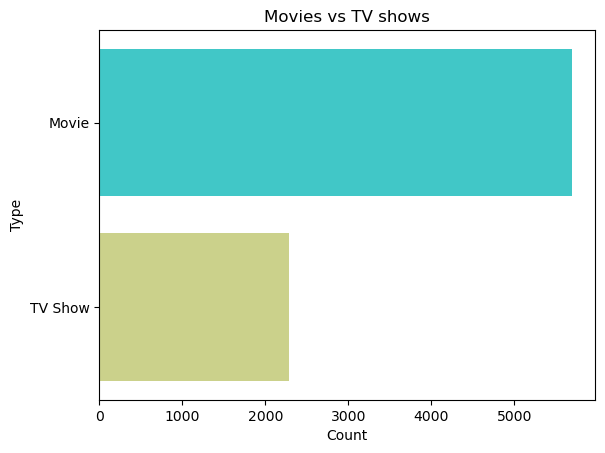

In [27]:
counts=df['type'].value_counts()
sns.barplot(x=counts.values,y=counts.index,palette='rainbow')
plt.title("Movies vs TV shows")
plt.xlabel("Count")
plt.ylabel("Type")

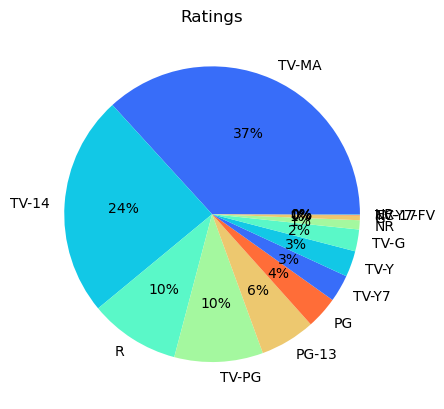

In [39]:
ratingCounts=df['rating'].value_counts()
colors=sns.color_palette("rainbow")
plt.pie(ratingCounts.values,labels=ratingCounts.index,colors=colors,autopct='%.0f%%')
plt.title("Ratings")
plt.show()

Text(0.5, 0, 'Mins')

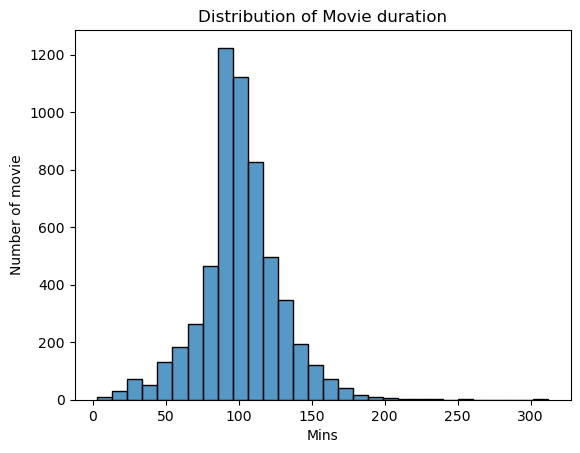

In [58]:
moivfd=df[df['type']=='Movie'].copy()
moivfd['duration_int']=moivfd['duration'].apply(lambda x:int(x[:-4]))
sns.histplot(moivfd['duration_int'],bins=30)
plt.title("Distribution of Movie duration")
plt.ylabel("Number of movie")
plt.xlabel("Mins")

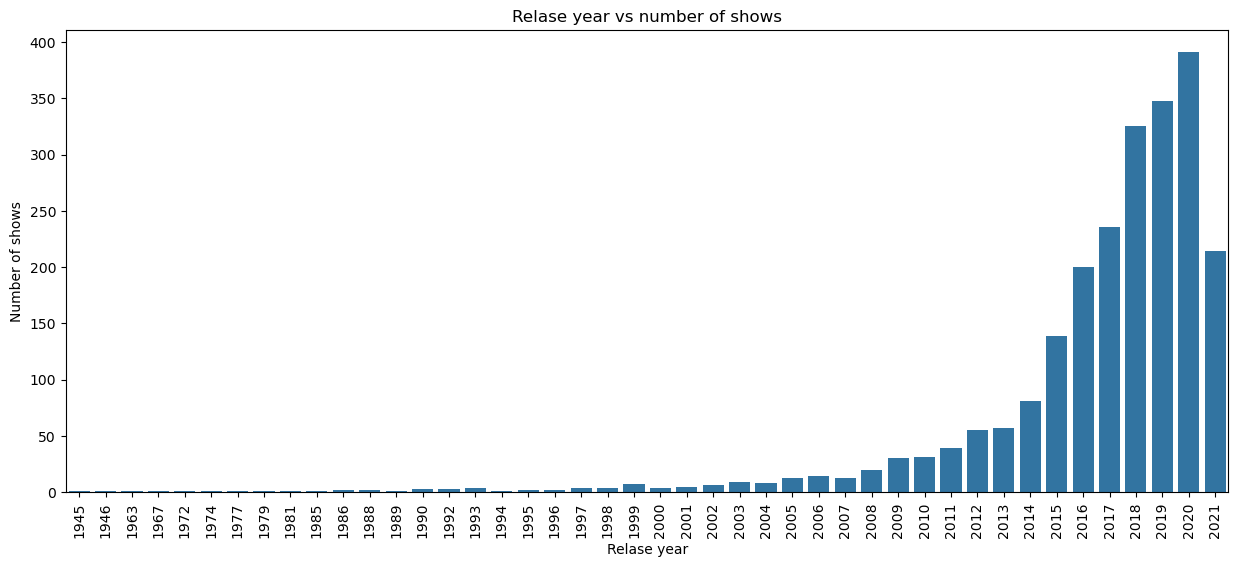

In [74]:
tvShowdf=df[df['type']=='TV Show'].copy()
showCounts=tvShowdf['release_year'].value_counts()
plt.figure(figsize=(15,6))
sns.barplot(x=showCounts.index, y=showCounts.values)
plt.xticks(rotation=90)
plt.title("Relase year vs number of shows")
plt.xlabel("Relase year")
plt.ylabel("Number of shows")
plt.show()

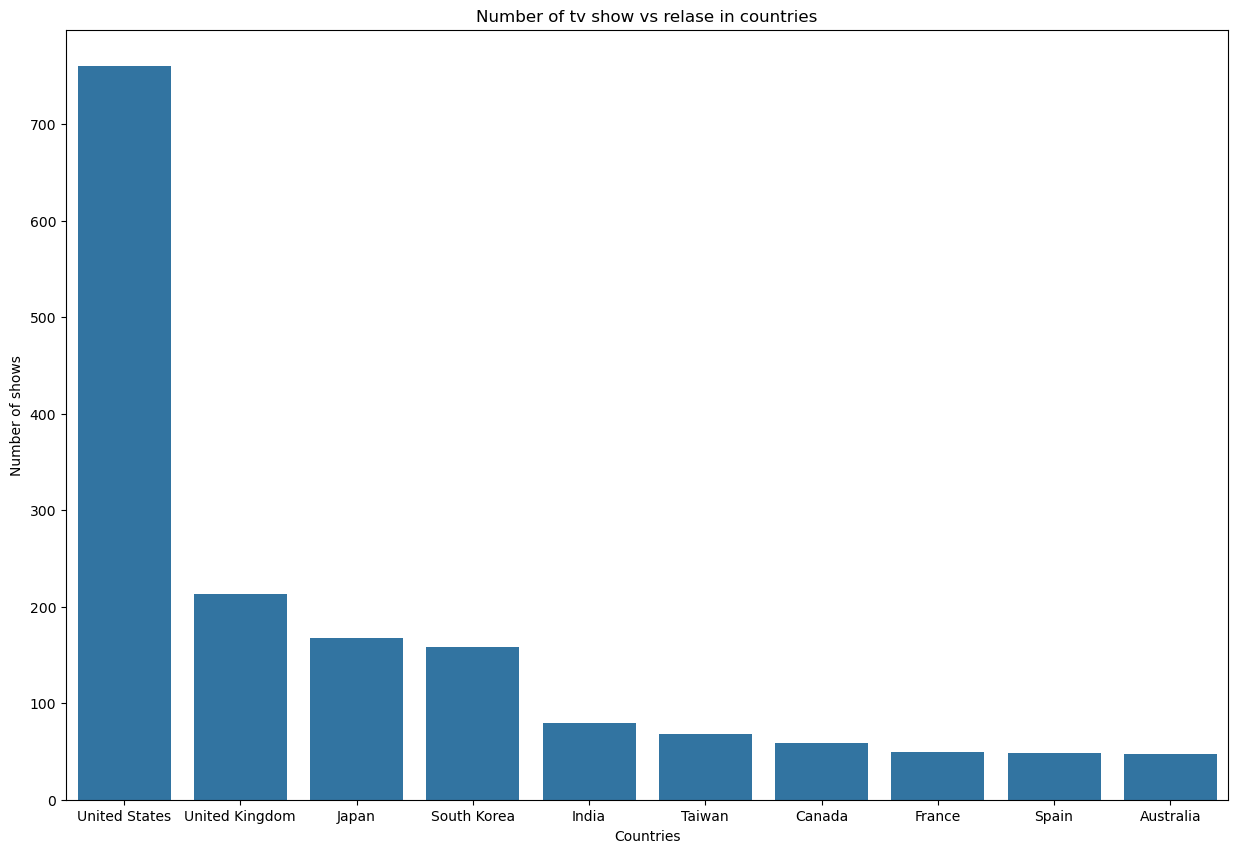

In [85]:
tvShowdf=df[df['type']=='TV Show'].copy()
showCounts=tvShowdf['country'].value_counts().sort_values(ascending=False).head(10)
plt.figure(figsize=(15,10))
sns.barplot(x=showCounts.index,y=showCounts.values)
plt.title("Number of tv show vs relase in countries")
plt.xlabel("Countries")
plt.ylabel("Number of shows")
plt.show()

In [86]:
print(f"index: {showCounts.index}")
print(f"Values: {showCounts.values}")

index: Index(['United States', 'United Kingdom', 'Japan', 'South Korea', 'India',
       'Taiwan', 'Canada', 'France', 'Spain', 'Australia'],
      dtype='object', name='country')
Values: [760 213 168 158  79  68  59  49  48  47]


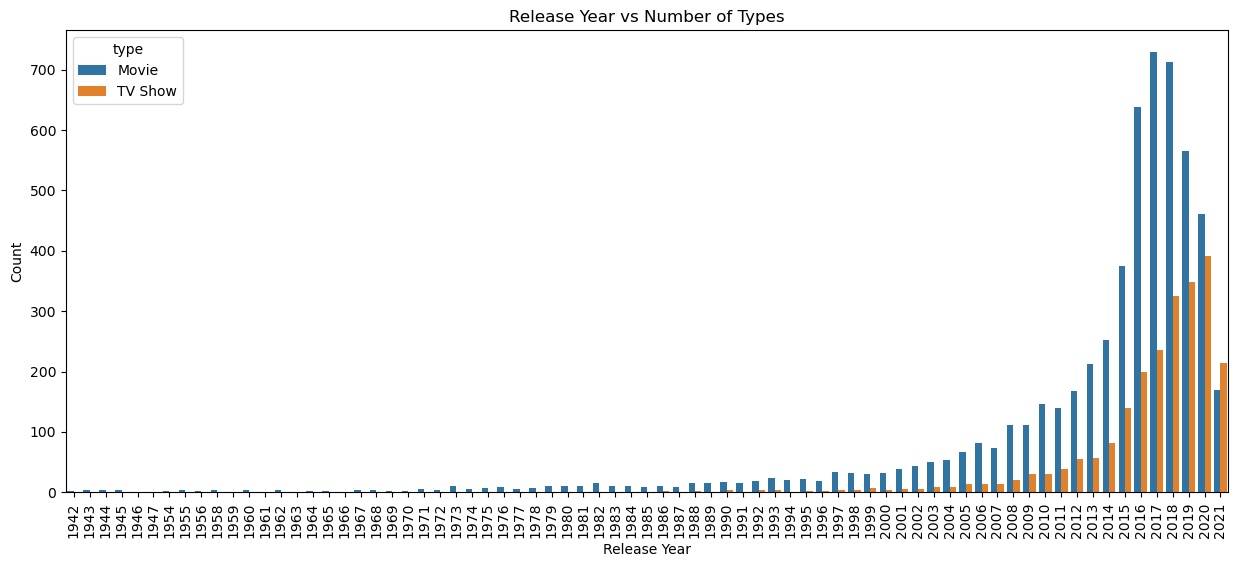

In [119]:

data = df.groupby(['release_year', 'type']).size().reset_index(name='count')

plt.figure(figsize=(15,6))
sns.barplot(data=data, x='release_year', y='count', hue='type')

plt.xticks(rotation=90)
plt.title("Release Year vs Number of Types")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()